imports and paths

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

DRIFT_PATH = PROCESSED_DIR / "04_centroid_drift"
COVERAGE_PATH = PROCESSED_DIR / "02_coverage_diagnostics"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "RQ1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables" / "RQ1"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

drift = pd.read_parquet(DRIFT_PATH / "centroid_drift_wpz_neighbors.parquet")
coverage = pd.read_parquet(COVERAGE_PATH / "coverage_diagnostics.parquet")

drift.head()

,modality,genre,window_start,window_end,next_window_start,next_window_end,window_gap,n_tracks_t,n_tracks_t1,cosine_similarity,cosine_distance
0,essentia,alternative metal,1995,1999,1996,2000,1,21,22,0.958763,0.041237
1,essentia,alternative metal,1996,2000,1997,2001,1,22,34,0.948263,0.051737
2,essentia,alternative metal,1997,2001,1998,2002,1,34,51,0.960931,0.039069
3,essentia,alternative metal,1998,2002,1999,2003,1,51,44,0.985195,0.014805
4,essentia,alternative metal,1999,2003,2000,2004,1,44,39,0.995410,0.004590


basic checks

In [35]:
print(drift.shape)
print(drift.columns)
print(drift["modality"].value_counts())
print(drift["window_gap"].value_counts().sort_index())

(18268, 11)
Index(['modality', 'genre', 'window_start', 'window_end', 'next_window_start',
       'next_window_end', 'window_gap', 'n_tracks_t', 'n_tracks_t1',
       'cosine_similarity', 'cosine_distance'],
      dtype='str')
modality
essentia         3076
lyrics_tf_idf    3076
word2vec         3076
mfcc             3076
musicnn          3076
vgg19            2888
Name: count, dtype: int64
window_gap
1    18268
Name: count, dtype: int64


# modality-level drift summary

In [36]:
modality_summary = (
    drift
    .groupby("modality")["cosine_distance"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
    .reset_index()
)

modality_summary.to_csv(
    TABLE_DIR / "rq1_modality_centroid_drift_summary.csv",
    index=False
)

modality_summary

,modality,count,mean,median,std,min,max
0,lyrics_tf_idf,3076,0.131162,0.117742,0.083778,0.000202,0.555454
1,vgg19,2888,0.098772,0.072895,0.091577,0.000118,0.839553
2,word2vec,3076,0.057076,0.033075,0.071246,0.000013,0.708198
3,essentia,3076,0.048244,0.028557,0.062655,0.000377,1.089618
4,mfcc,3076,0.048986,0.026090,0.064387,0.000040,0.586259
5,musicnn,3076,0.019336,0.007909,0.034674,0.000069,0.405253


<Figure size 1000x500 with 0 Axes>

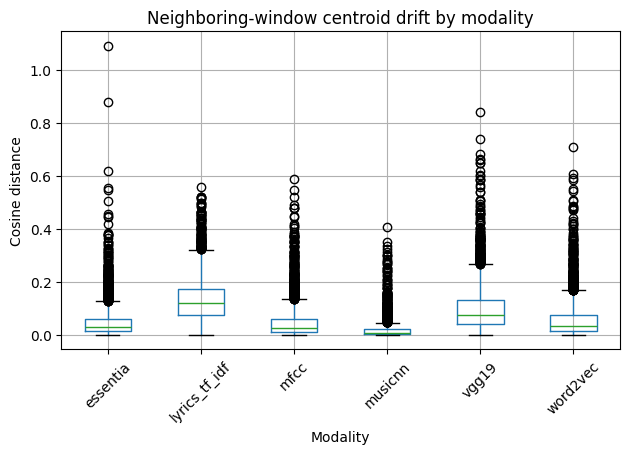

In [37]:
plt.figure(figsize=(10, 5))

drift.boxplot(
    column="cosine_distance",
    by="modality",
    rot=45
)

plt.title("Neighboring-window centroid drift by modality")
plt.suptitle("")
plt.xlabel("Modality")
plt.ylabel("Cosine distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_centroid_drift_boxplot_by_modality_with_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_centroid_drift_boxplot_by_modality_with_outliers.pdf",
    bbox_inches="tight"
)

plt.show()

remove outlier for better visualization

<Figure size 1000x500 with 0 Axes>

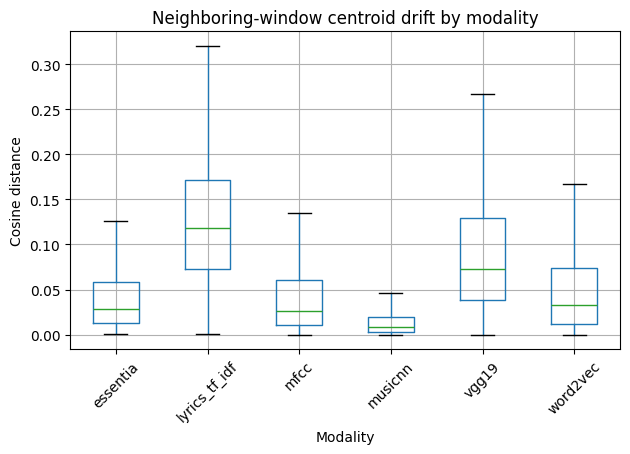

In [38]:
plt.figure(figsize=(10, 5))

drift.boxplot(
    column="cosine_distance",
    by="modality",
    rot=45,
    showfliers=False
)

plt.title("Neighboring-window centroid drift by modality")
plt.suptitle("")
plt.xlabel("Modality")
plt.ylabel("Cosine distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_centroid_drift_boxplot_by_modality_no_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_centroid_drift_boxplot_by_modality_no_outliers.pdf",
    bbox_inches="tight"
)

plt.show()

# minimal interpretation
- lyrics_tf_idf has the highest median and widest central spread
- vgg19 has the second highest central drift
- word2vec, mfcc, and essentia are lower and relatively similar
- musicnn has the lowest centroid drift
- the boxplot without outlier markers is easier to interpret for central modality differences

# temporal development of centroid drift

In [39]:
window_summary = (
    drift
    .groupby(["modality", "window_start"])["cosine_distance"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

window_summary = window_summary.rename(
    columns={
        "count": "n_drift_comparisons",
        "mean": "mean_drift",
        "median": "median_drift",
        "std": "std_drift"
    }
)

window_summary.sort_values("n_drift_comparisons").head(20)

,modality,window_start,n_drift_comparisons,mean_drift,median_drift,std_drift
0,essentia,1951,1,0.244992,0.244992,NaN
1,essentia,1952,1,0.119405,0.119405,NaN
2,essentia,1953,1,0.056648,0.056648,NaN
3,essentia,1954,1,0.029422,0.029422,NaN
343,word2vec,1954,1,0.022254,0.022254,NaN
69,lyrics_tf_idf,1952,1,0.274070,0.274070,NaN
70,lyrics_tf_idf,1953,1,0.178551,0.178551,NaN
71,lyrics_tf_idf,1954,1,0.143927,0.143927,NaN
68,lyrics_tf_idf,1951,1,0.483566,0.483566,NaN
342,word2vec,1953,1,0.035480,0.035480,NaN


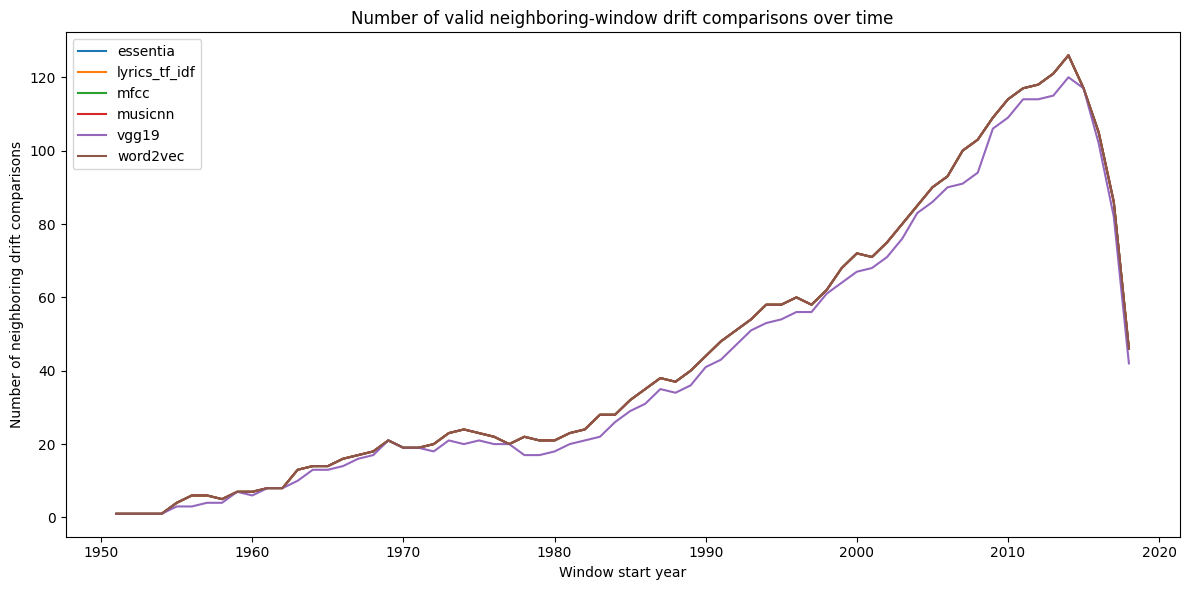

In [40]:
plt.figure(figsize=(12, 6))

for modality, modality_data in window_summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["n_drift_comparisons"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Number of neighboring drift comparisons")
plt.title("Number of valid neighboring-window drift comparisons over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_drift_comparison_count_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_drift_comparison_count_over_time.pdf",
    bbox_inches="tight"
)

plt.show()

# coverage and drift correlation

In [41]:
coverage_drift_correlation = (
    window_summary
    .groupby("modality")
    .apply(
        lambda x: pd.Series({
            "corr_coverage_mean_drift": x["n_drift_comparisons"].corr(x["mean_drift"]),
            "corr_coverage_median_drift": x["n_drift_comparisons"].corr(x["median_drift"]),
            "n_windows": len(x)
        })
    )
    .reset_index()
)

coverage_drift_correlation.to_csv(
    TABLE_DIR / "rq1_coverage_drift_correlation.csv",
    index=False
)

coverage_drift_correlation

,modality,corr_coverage_mean_drift,corr_coverage_median_drift,n_windows
0,essentia,-0.506458,-0.561628,68.0
1,lyrics_tf_idf,-0.456871,-0.470154,68.0
2,mfcc,-0.410757,-0.412465,68.0
3,musicnn,-0.400910,-0.374612,68.0
4,vgg19,-0.424854,-0.494190,68.0
5,word2vec,-0.284417,-0.314563,68.0


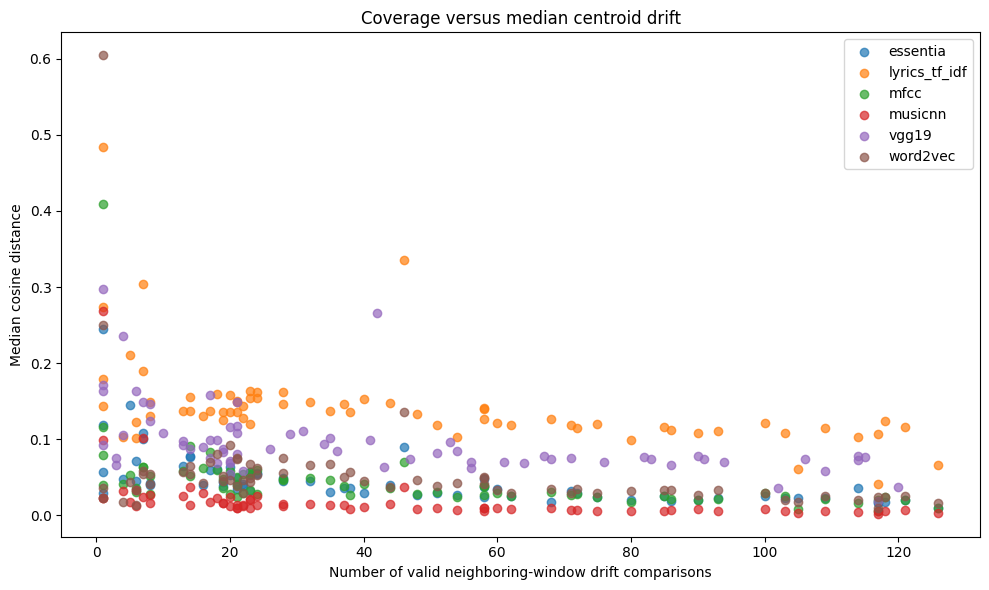

In [42]:
plt.figure(figsize=(10, 6))

for modality, modality_data in window_summary.groupby("modality"):
    plt.scatter(
        modality_data["n_drift_comparisons"],
        modality_data["median_drift"],
        label=modality,
        alpha=0.7
    )

plt.xlabel("Number of valid neighboring-window drift comparisons")
plt.ylabel("Median cosine distance")
plt.title("Coverage versus median centroid drift")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_coverage_vs_median_centroid_drift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_coverage_vs_median_centroid_drift.pdf",
    bbox_inches="tight"
)

plt.show()

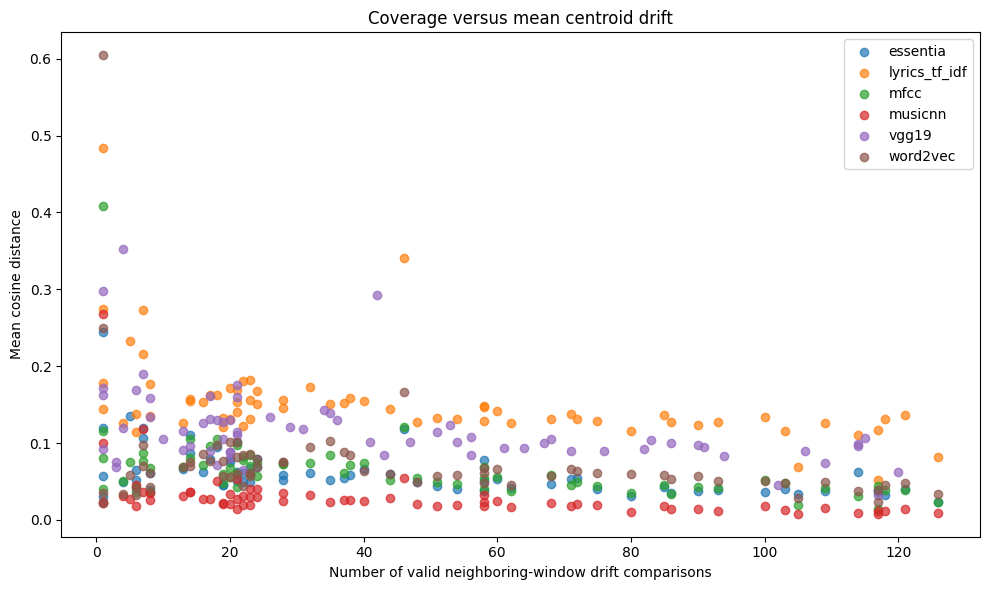

In [43]:
plt.figure(figsize=(10, 6))

for modality, modality_data in window_summary.groupby("modality"):
    plt.scatter(
        modality_data["n_drift_comparisons"],
        modality_data["mean_drift"],
        label=modality,
        alpha=0.7
    )

plt.xlabel("Number of valid neighboring-window drift comparisons")
plt.ylabel("Mean cosine distance")
plt.title("Coverage versus mean centroid drift")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_coverage_vs_mean_centroid_drift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_coverage_vs_mean_centroid_drift.pdf",
    bbox_inches="tight"
)

plt.show()

# interpretation
- the correlation table checks whether windows with fewer valid comparisons tend to show higher or lower drift
- negative correlations would mean that lower coverage is associated with higher drift
- the scatter plots make this relationship visible directly
- this is important because low-coverage windows can create unstable drift estimates

# drift and coverage together

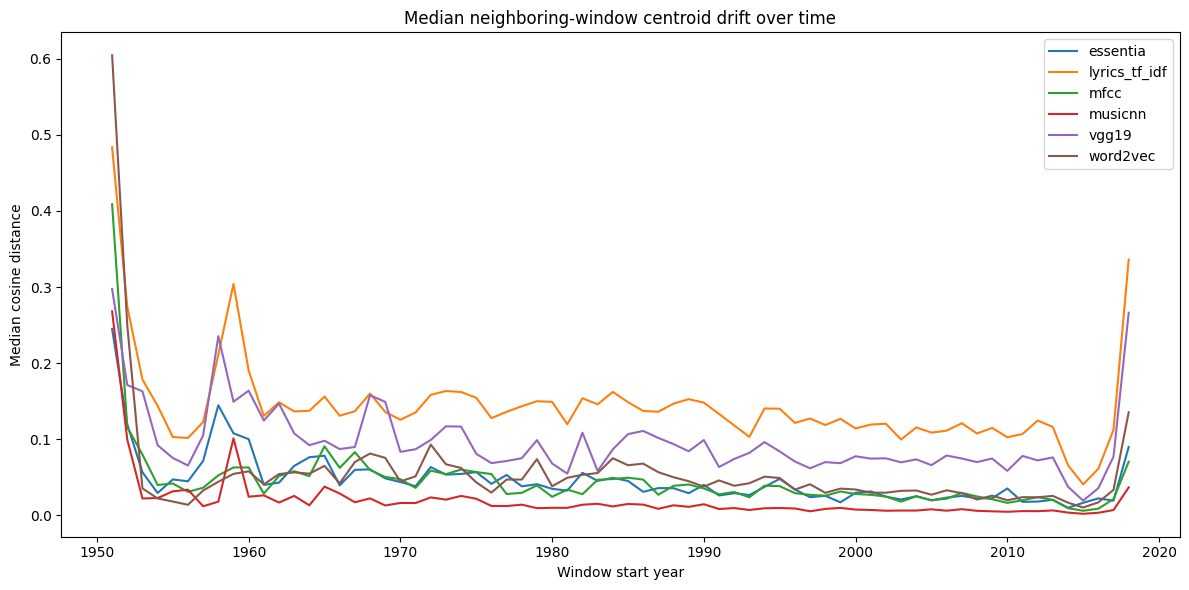

In [44]:
plt.figure(figsize=(12, 6))

for modality, modality_data in window_summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["median_drift"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Median cosine distance")
plt.title("Median neighboring-window centroid drift over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_median_centroid_drift_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_median_centroid_drift_over_time.pdf",
    bbox_inches="tight"
)

plt.show()

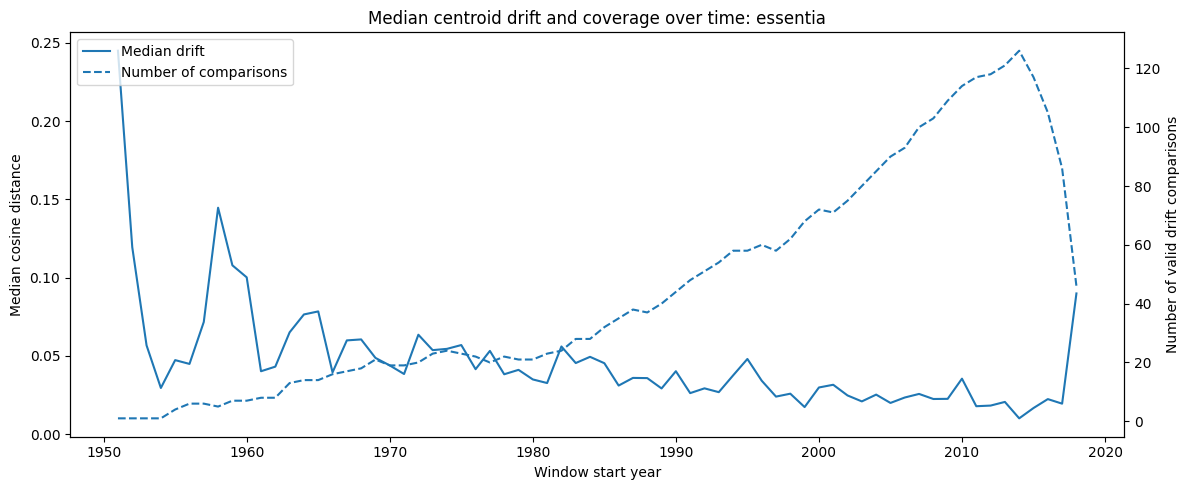

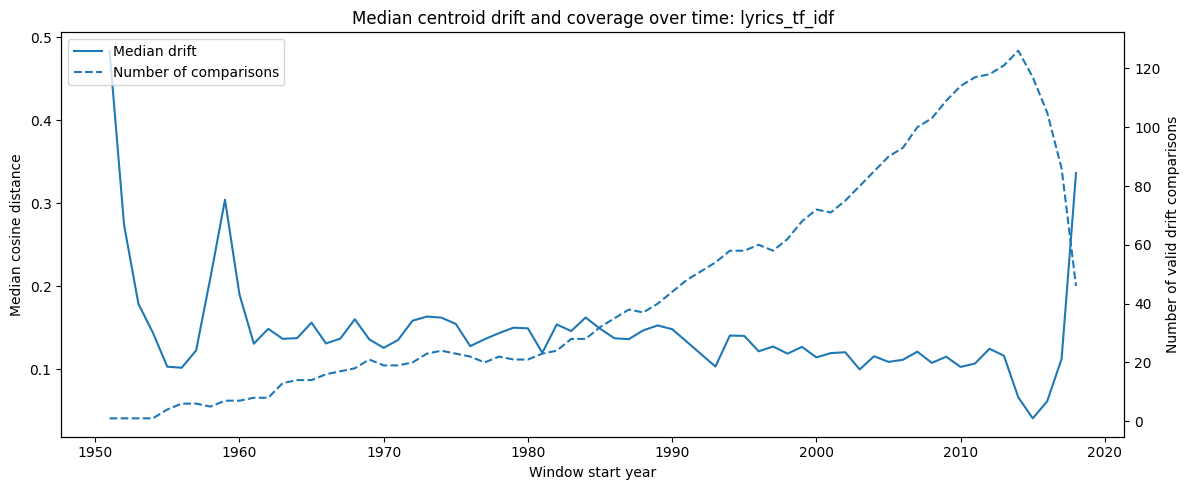

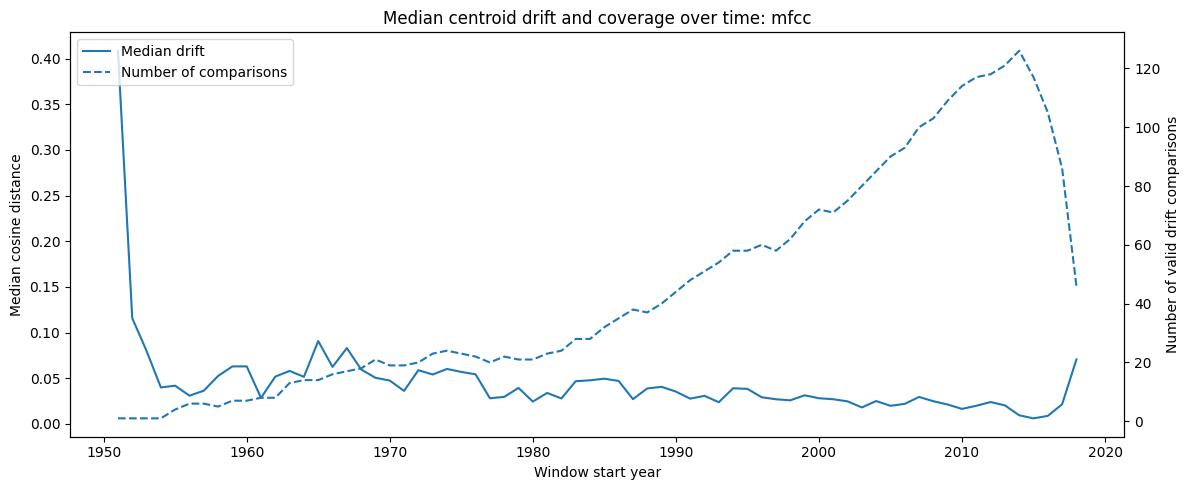

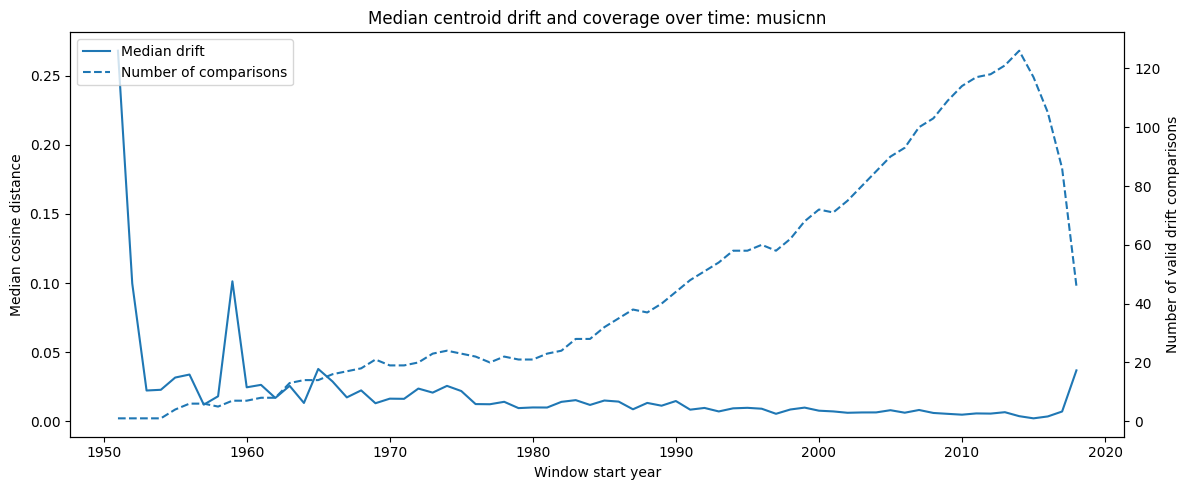

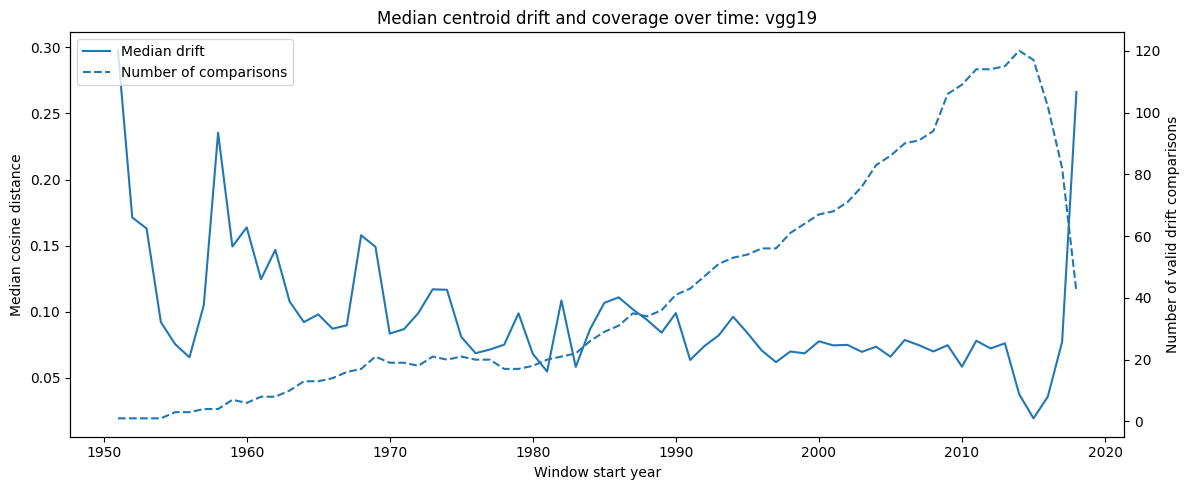

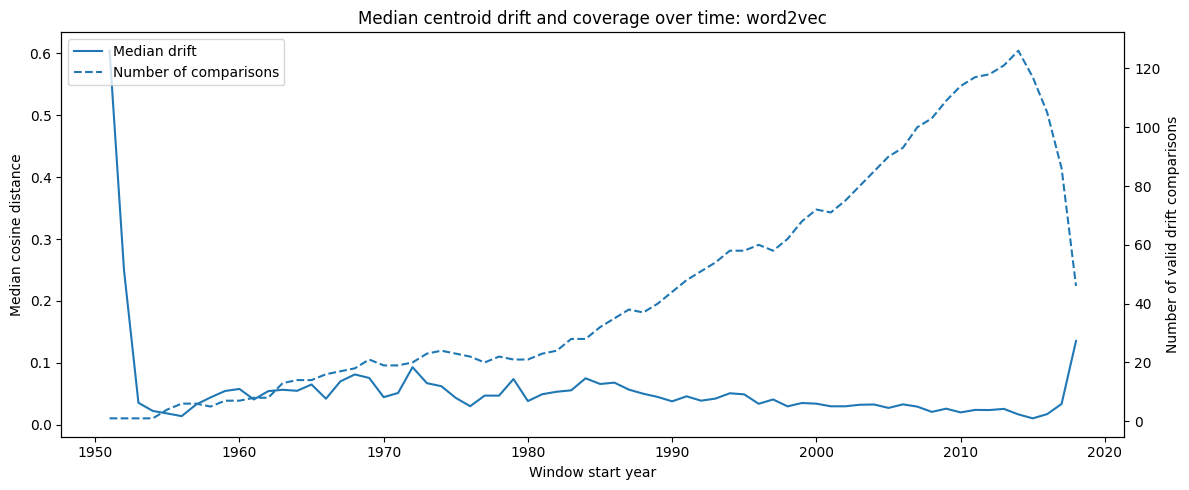

In [45]:
for modality, modality_data in window_summary.groupby("modality"):
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(
        modality_data["window_start"],
        modality_data["median_drift"],
        label="Median drift"
    )

    ax1.set_xlabel("Window start year")
    ax1.set_ylabel("Median cosine distance")

    ax2 = ax1.twinx()

    ax2.plot(
        modality_data["window_start"],
        modality_data["n_drift_comparisons"],
        linestyle="--",
        label="Number of comparisons"
    )

    ax2.set_ylabel("Number of valid drift comparisons")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper left"
    )

    plt.title(f"Median centroid drift and coverage over time: {modality}")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"rq1_median_drift_with_coverage_{modality}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        FIGURE_DIR / f"rq1_median_drift_with_coverage_{modality}.pdf",
        bbox_inches="tight"
    )

    plt.show()

# interpretation:
- lyrics_tf_idf has the highest drift across most periods
- vgg19 is usually second highest
- musicnn is consistently lowest
- essentia, mfcc, and word2vec are lower and closer together
---
- early years have extremely low coverage
- coverage increases strongly toward the 2000s/2010s
- coverage drops again at the end

### filter low-coverage windows

In [46]:
min_comparisons = 20

window_summary_filtered = window_summary[
    window_summary["n_drift_comparisons"] >= min_comparisons
]

coverage_filter_summary = (
    window_summary
    .assign(kept=lambda df: df["n_drift_comparisons"] >= min_comparisons)
    .groupby(["modality", "kept"])
    .size()
    .reset_index(name="n_windows")
)

coverage_filter_summary.to_csv(
    TABLE_DIR / "rq1_coverage_filter_summary.csv",
    index=False
)

coverage_filter_summary

,modality,kept,n_windows
0,essentia,False,20
1,essentia,True,48
2,lyrics_tf_idf,False,20
3,lyrics_tf_idf,True,48
4,mfcc,False,20
5,mfcc,True,48
6,musicnn,False,20
7,musicnn,True,48
8,vgg19,False,24
9,vgg19,True,44


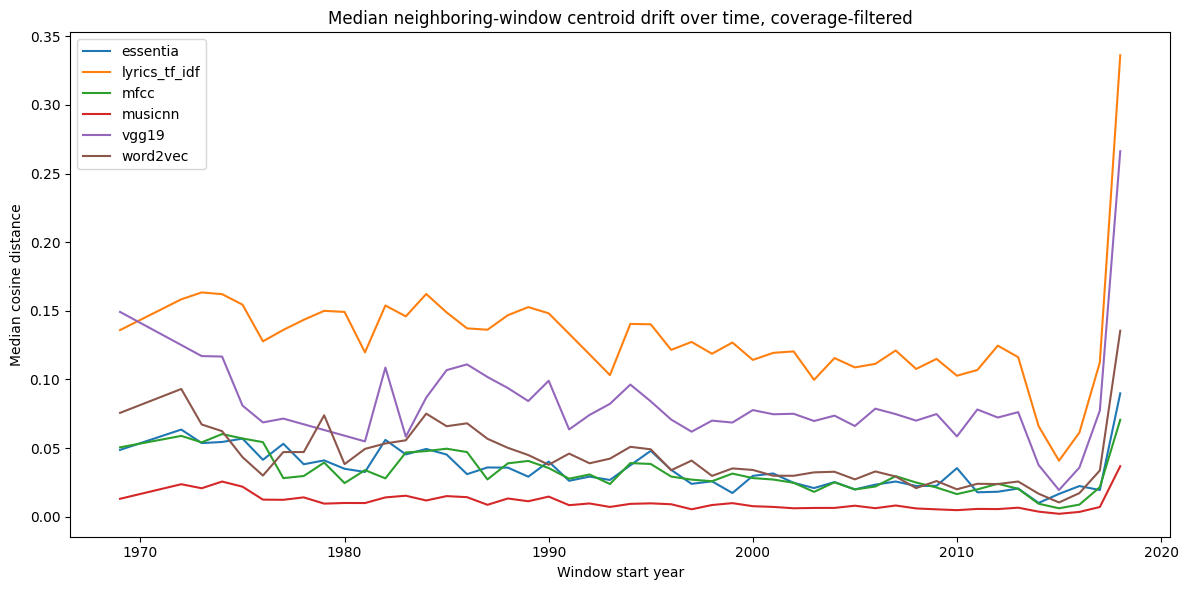

In [47]:
plt.figure(figsize=(12, 6))

for modality, modality_data in window_summary_filtered.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["median_drift"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Median cosine distance")
plt.title("Median neighboring-window centroid drift over time, coverage-filtered")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_median_centroid_drift_over_time_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_median_centroid_drift_over_time_filtered.pdf",
    bbox_inches="tight"
)

plt.show()

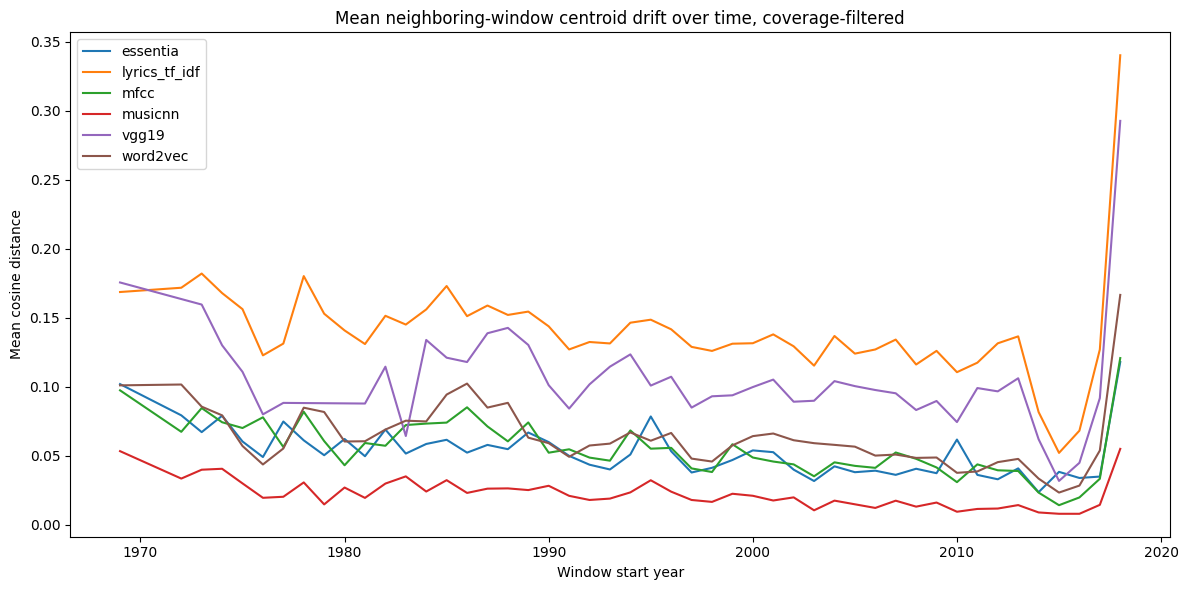

In [48]:
plt.figure(figsize=(12, 6))

for modality, modality_data in window_summary_filtered.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["mean_drift"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Mean cosine distance")
plt.title("Mean neighboring-window centroid drift over time, coverage-filtered")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_mean_centroid_drift_over_time_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_mean_centroid_drift_over_time_filtered.pdf",
    bbox_inches="tight"
)

plt.show()

In [49]:
filtered_window_keys = window_summary_filtered[
    ["modality", "window_start"]
]

drift_filtered = drift.merge(
    filtered_window_keys,
    on=["modality", "window_start"],
    how="inner"
)

modality_summary_filtered = (
    drift_filtered
    .groupby("modality")["cosine_distance"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
    .reset_index()
)

modality_summary_filtered.to_csv(
    TABLE_DIR / "rq1_modality_centroid_drift_summary_filtered.csv",
    index=False
)

modality_summary_filtered

,modality,count,mean,median,std,min,max
0,lyrics_tf_idf,2891,0.129477,0.115574,0.083893,0.000202,0.555454
1,vgg19,2650,0.096559,0.070511,0.091199,0.000118,0.738931
2,word2vec,2891,0.055991,0.031882,0.070443,0.000013,0.708198
3,essentia,2891,0.046555,0.027337,0.062257,0.000377,1.089618
4,mfcc,2891,0.047315,0.024597,0.063631,0.000040,0.586259
5,musicnn,2891,0.018270,0.007285,0.033549,0.000069,0.350224


# interpretation
- lyrics_tf_idf has the highest centroid drift across most of the filtered period
- vgg19 is usually the second highest
- musicnn has consistently the lowest drift
- essentia, mfcc, and word2vec are lower and closer together
- the final spike around 2018 still needs caution because it is close to the dataset edge
- the coverage-filtered plots are the main temporal plots, while the unfiltered plots are diagnostic

#### outliers

In [50]:
top_outliers = (
    drift
    .sort_values("cosine_distance", ascending=False)
    [
        [
            "modality",
            "genre",
            "window_start",
            "window_end",
            "next_window_start",
            "next_window_end",
            "cosine_similarity",
            "cosine_distance",
            "n_tracks_t",
            "n_tracks_t1",
        ]
    ]
    .head(30)
)

top_outliers.to_csv(
    TABLE_DIR / "rq1_top_centroid_drift_outliers.csv",
    index=False
)

top_outliers

,modality,genre,window_start,window_end,next_window_start,next_window_end,cosine_similarity,cosine_distance,n_tracks_t,n_tracks_t1
965,essentia,folk rock,2010,2014,2011,2015,-0.089618,1.089618,25,28
970,essentia,folk rock,2015,2019,2016,2020,0.121423,0.878577,39,32
15695,vgg19,classic rock,1958,1962,1959,1963,0.160447,0.839553,22,41
16660,vgg19,indie pop,2018,2022,2019,2023,0.261069,0.738931,410,100
8916,word2vec,ska,2013,2017,2014,2018,0.291802,0.708198,20,32
17460,vgg19,post-punk,2018,2022,2019,2023,0.318918,0.681082,127,26
17226,vgg19,nu metal,1993,1997,1994,1998,0.336917,0.663083,24,36
17588,vgg19,progressive rock,1987,1991,1988,1992,0.342513,0.657487,42,34
16749,vgg19,industrial metal,2007,2011,2008,2012,0.352184,0.647816,43,45
16704,vgg19,industrial,1989,1993,1990,1994,0.352851,0.647149,21,36


# final interpretation
- centroid-based temporal genre drift differs by modality
- lyrics_tf_idf shows the strongest drift, followed by vgg19
- musicnn is the most stable representation
- coverage affects the temporal interpretation, especially at the dataset edges